# Checking the Emission Line Ratios from the EmFit Catalog

In notebook `emfit-vac.ipynb` I download a sample of spectra into `../data/spectra/`. I will do my own measurements of their line ratios to double check that these are reliable.

In [1]:
%matplotlib widget

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table

In [3]:
emps = Table.read('../data/emp-candidates.fits', format='fits').to_pandas()

In [4]:
targetid = emps['TARGETID'].loc[0]
z = emps['Z'].loc[0]
spec = Table.read(f'../data/spectra/{targetid}.fits', format='fits')

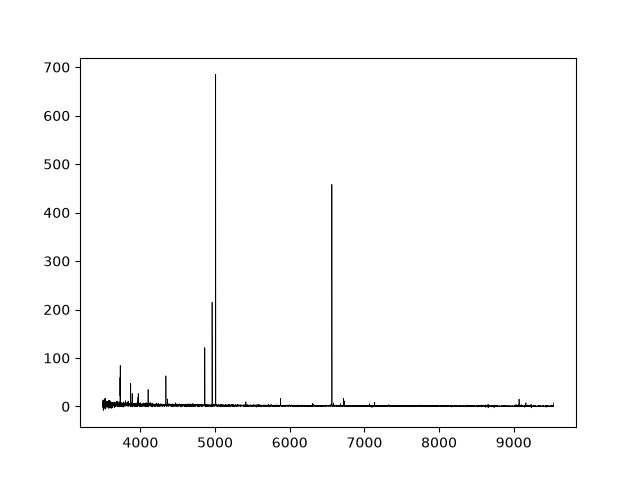

In [5]:
plt.figure(1)
plt.clf()

plt.plot(spec['wavelength'] / (1 + z), spec['flux'], color='black', lw=0.5)


plt.show()

In [6]:
def make_gaussian_model(centers):
    centers = np.asarray(centers)
    n_lines = len(centers)

    def model(wave, z, sigma, *args, m=None, n=None):
        wave = np.asarray(wave)

        if len(args) == n_lines + 2:
            fluxes = np.asarray(args[:n_lines])
            m = args[n_lines] if m is None else m
            n = args[n_lines + 1] if n is None else n
        elif len(args) == n_lines and m is not None and n is not None:
            fluxes = np.asarray(args)
        else:
            raise ValueError(
                f"Expected {n_lines} fluxes and 2 continuum parameters (m, n), got {len(args)} positional arguments."
            )

        # Linear continuum
        continuum = m * wave + n

        # Gaussians evaluated across all lines: shape (n_lines, len(wave))
        # Broadcasting: wave[None, :] - (centers * (1 + z))[:, None]
        shifted_centers = (centers * (1 + z))[:, None]
        exponent = -0.5 * ((wave[None, :] - shifted_centers) / sigma) ** 2
        gaussians = np.sum((fluxes[:, None] / (sigma * np.sqrt(2 * np.pi))) * np.exp(exponent), axis=0)

        return continuum + gaussians

    return model

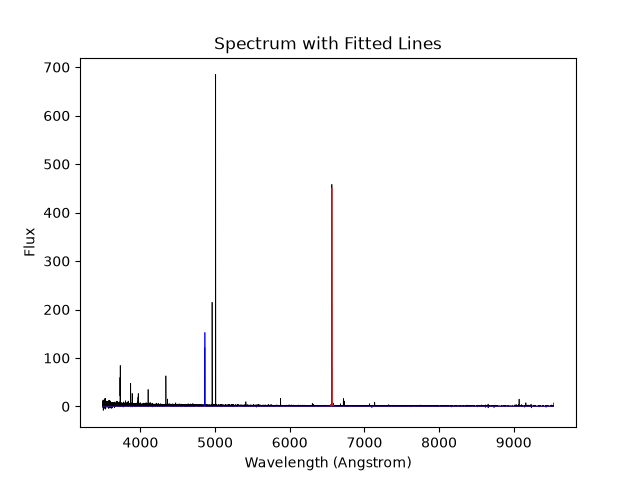

In [7]:
f_ha = make_gaussian_model([6548.1, 6562.8, 6583.4])(spec['wavelength'], z+0.00025, 1.5, 10, 1700, 10, m=0, n=0)
f_hb = make_gaussian_model([4863.0])(spec['wavelength'], z+0.00025, 1.5, 1700 / 2.86, m=0, n=0)

plt.figure(2)
plt.clf()

plt.xlabel('Wavelength (Angstrom)')
plt.ylabel('Flux')
plt.title('Spectrum with Fitted Lines')

plt.plot(spec['wavelength'] / (1 + z), spec['flux'], color='black', lw=0.5)
plt.plot(spec['wavelength'] / (1 + z), f_ha, color='red', lw=0.5)
plt.plot(spec['wavelength'] / (1 + z), f_hb, color='blue', lw=0.5)

plt.show()

In [8]:
def initial_guesses(z, centers, continuum_windows, data, sigma=1.5):
    """
    Estimate initial parameters for the multi-Gaussian emission line + linear continuum fit.

    Parameters
    ----------
    z : float
        Initial redshift guess.
    centers : list or array-like
        Rest-frame line central wavelengths (in Angstroms).
    continuum_windows : list of 2 tuples/lists
        Two rest-frame wavelength windows [(w1_min, w1_max), (w2_min, w2_max)]
        used to estimate the continuum.
    data : astropy.table.Table, pandas.DataFrame, dict, or tuple of (wave, flux)
        Observed spectrum containing wavelength and flux.
    sigma : float, optional
        Initial line width guess in Angstroms (default is 1.5).

    Returns
    -------
    p0 : list
        Initial parameter list: [z, sigma, flux_1, ..., flux_N, m, n]
    """
    # Extract wavelength and flux from input data
    if isinstance(data, (tuple, list)) and len(data) == 2:
        wave, flux = np.asarray(data[0]), np.asarray(data[1])
    elif hasattr(data, '__getitem__'):
        wave = np.asarray(data['wavelength'] if 'wavelength' in data else data['wave'])
        flux = np.asarray(data['flux'])
    else:
        raise ValueError("data must be a table/dict with 'wavelength'/'flux' or a (wave, flux) tuple.")

    centers = np.asarray(centers)
    rest_wave = wave / (1 + z)

    # Continuum estimation from the two rest-frame windows
    w1, w2 = continuum_windows
    mask_w1 = (rest_wave >= w1[0]) & (rest_wave <= w1[1])
    mask_w2 = (rest_wave >= w2[0]) & (rest_wave <= w2[1])

    # Mean observed wavelength and flux in each window
    obs_center_1 = np.mean(wave[mask_w1]) if np.any(mask_w1) else np.mean(w1) * (1 + z)
    obs_center_2 = np.mean(wave[mask_w2]) if np.any(mask_w2) else np.mean(w2) * (1 + z)
    flux_w1 = np.mean(flux[mask_w1]) if np.any(mask_w1) else 0.0
    flux_w2 = np.mean(flux[mask_w2]) if np.any(mask_w2) else 0.0

    # Linear continuum: flux_cont = m * wave_obs + n
    m = (flux_w2 - flux_w1) / (obs_center_2 - obs_center_1)
    n = flux_w1 - m * obs_center_1

    # Estimate line fluxes
    fluxes = []
    # Search half-width around each line center (in rest-frame Angstroms)
    search_half_width = max(3.0 * sigma / (1 + z), 5.0)

    for c in centers:
        line_mask = (rest_wave >= c - search_half_width) & (rest_wave <= c + search_half_width)
        c_obs = c * (1 + z)
        cont_at_line = m * c_obs + n

        if np.any(line_mask):
            peak_flux_density = np.max(flux[line_mask]) - cont_at_line
            # Total integrated flux = peak_height * sigma * sqrt(2*pi)
            flux_guess = max(peak_flux_density, 0.1) * sigma * np.sqrt(2 * np.pi)
        else:
            flux_guess = 1.0

        fluxes.append(float(flux_guess))

    p0 = [float(z), float(sigma)] + fluxes + [float(m), float(n)]
    return p0

In [9]:
ha_n2_windows = [(6450, 6500), (6620, 6670)]  # Rest-frame windows for continuum estimation
print(initial_guesses(z, [6548.1, 6562.8, 6583.4], ha_n2_windows, (spec['wavelength'], spec['flux']), sigma=1.5))

[0.030633923986022306, 1.5, 10.756231957918958, 1718.3260463921476, 21.599097544564934, -0.00044390197657783045, 4.1774699973783616]


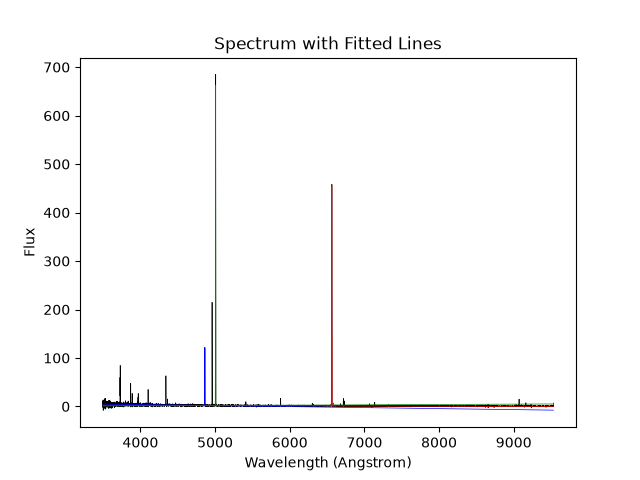

In [10]:
p0_ha = initial_guesses(z, [6548.1, 6562.8, 6583.4], ha_n2_windows, (spec['wavelength'], spec['flux']), sigma=1.5)
f_ha = make_gaussian_model([6548.1, 6562.8, 6583.4])(spec['wavelength'], *p0_ha)

p0_hb = initial_guesses(z, [4863.0], [(4800, 4850), (4890, 4940)], (spec['wavelength'], spec['flux']), sigma=1.5)
f_hb = make_gaussian_model([4863.0])(spec['wavelength'], *p0_hb)

p0_o3 = initial_guesses(z, [5007.0], [(4890, 4940), (5030, 5080)], (spec['wavelength'], spec['flux']), sigma=1.5)
f_o3 = make_gaussian_model([5007.0])(spec['wavelength'], *p0_o3)


plt.figure(3)
plt.clf()

plt.xlabel('Wavelength (Angstrom)')
plt.ylabel('Flux')
plt.title('Spectrum with Fitted Lines')

plt.plot(spec['wavelength'] / (1 + z), spec['flux'], color='black', lw=0.5)
plt.plot(spec['wavelength'] / (1 + z), f_ha, color='red', lw=0.5)
plt.plot(spec['wavelength'] / (1 + z), f_hb, color='blue', lw=0.5)
plt.plot(spec['wavelength'] / (1 + z), f_o3, color='green', lw=0.5)

plt.show()

In [11]:
# Wavelengths, all vacuum. Copied from Lime
ha_n2 = [6549.850000, 6564.610000, 6585.280000]
hb = [4862.683000]
o3_b = [5008.240000]

# Continuum windows
ha_n2_window = [(6450, 6500), (6620, 6670)]
hb_window = [(4800, 4850), (4890, 4940)]
o3_b_window = [(4890, 4940), (5030, 5080)]

In [12]:
from scipy.optimize import curve_fit

# Helper function to generate bounds: sigma > 0, fluxes > 0, z and (m, n) unbounded
def get_bounds(n_lines):
    lower = [-np.inf, 0.0] + [0.0] * n_lines + [-np.inf, -np.inf]
    upper = [np.inf, np.inf] + [np.inf] * n_lines + [np.inf, np.inf]
    return (lower, upper)

# Fit H-alpha + [N II]
mask_ha = (
    (spec['wavelength'] / (1 + z) >= ha_n2_window[0][0])
    & (spec['wavelength'] / (1 + z) <= ha_n2_window[1][1])
    & (spec['ivar'] > 0)
)
sigma_ha = 1.0 / np.sqrt(spec['ivar'][mask_ha])
model_ha = make_gaussian_model(ha_n2)
p0_ha = initial_guesses(z, ha_n2, ha_n2_window, (spec['wavelength'], spec['flux']))
popt_ha, pcov_ha = curve_fit(
    model_ha,
    spec['wavelength'][mask_ha],
    spec['flux'][mask_ha],
    p0=p0_ha,
    sigma=sigma_ha,
    absolute_sigma=True,
    bounds=get_bounds(len(ha_n2)),
)

# Fit H-beta
mask_hb = (
    (spec['wavelength'] / (1 + z) >= hb_window[0][0])
    & (spec['wavelength'] / (1 + z) <= hb_window[1][1])
    & (spec['ivar'] > 0)
)
sigma_hb = 1.0 / np.sqrt(spec['ivar'][mask_hb])
model_hb = make_gaussian_model(hb)
p0_hb = initial_guesses(z, hb, hb_window, (spec['wavelength'], spec['flux']))
popt_hb, pcov_hb = curve_fit(
    model_hb,
    spec['wavelength'][mask_hb],
    spec['flux'][mask_hb],
    p0=p0_hb,
    sigma=sigma_hb,
    absolute_sigma=True,
    bounds=get_bounds(len(hb)),
)

# Fit [O III] 5007 (o3_b)
mask_o3 = (
    (spec['wavelength'] / (1 + z) >= o3_b_window[0][0])
    & (spec['wavelength'] / (1 + z) <= o3_b_window[1][1])
    & (spec['ivar'] > 0)
)
sigma_o3 = 1.0 / np.sqrt(spec['ivar'][mask_o3])
model_o3_b = make_gaussian_model(o3_b)
p0_o3_b = initial_guesses(z, o3_b, o3_b_window, (spec['wavelength'], spec['flux']))
popt_o3_b, pcov_o3_b = curve_fit(
    model_o3_b,
    spec['wavelength'][mask_o3],
    spec['flux'][mask_o3],
    p0=p0_o3_b,
    sigma=sigma_o3,
    absolute_sigma=True,
    bounds=get_bounds(len(o3_b)),
)

print("H-alpha + [N II] fit parameters (z, sigma, flux_NII_a, flux_Ha, flux_NII_b, m, n):")
print(popt_ha)

print("\nH-beta fit parameters (z, sigma, flux_Hb, m, n):")
print(popt_hb)

print("\n[O III] 5007 fit parameters (z, sigma, flux_OIII, m, n):")
print(popt_o3_b)

H-alpha + [N II] fit parameters (z, sigma, flux_NII_a, flux_Ha, flux_NII_b, m, n):
[ 3.06375426e-02  7.18301298e-01  5.64144344e+00  7.74415041e+02
  1.03383243e+01 -5.68082381e-04  5.09703466e+00]

H-beta fit parameters (z, sigma, flux_Hb, m, n):
[ 3.06156834e-02  7.27202223e-01  2.47273613e+02 -2.30386169e-03
  1.36077274e+01]

[O III] 5007 fit parameters (z, sigma, flux_OIII, m, n):
[ 3.06220285e-02  6.56345705e-01  1.04753230e+03 -1.80113763e-03
  1.16458923e+01]


In [13]:
from pathlib import Path

LINE_GROUPS = {
    "ha_n2": (ha_n2, ha_n2_window),
    "hb": (hb, hb_window),
    "o3_b": (o3_b, o3_b_window),
}


def fit_spectrum_lines(fits_path, z=None, emp_catalog_path="../data/emp-candidates.fits"):
    """
    Fit the ha_n2, hb and o3_b emission-line complexes for a single spectrum.

    Parameters
    ----------
    fits_path : str or Path
        Path to a spectrum fits file in `data/spectra/` (columns 'wavelength', 'flux', 'ivar').
    z : float, optional
        Redshift to use as the fit's initial guess. If not given, it is looked up
        by TARGETID (parsed from the file name) in `emp_catalog_path`.
    emp_catalog_path : str, optional
        Path to the catalog used to look up the redshift when `z` is not given.

    Returns
    -------
    results : dict
        Mapping from line-group name ("ha_n2", "hb", "o3_b") to a dict with
        keys "popt", "pcov", "perr" (1-sigma errors) and "param_names".
    """
    spec = Table.read(fits_path, format="fits")

    if z is None:
        targetid = int(Path(fits_path).stem)
        emps_catalog = Table.read(emp_catalog_path, format="fits").to_pandas()
        matches = emps_catalog.loc[emps_catalog["TARGETID"] == targetid, "Z"]
        if matches.empty:
            raise ValueError(f"TARGETID {targetid} not found in {emp_catalog_path}; pass z explicitly.")
        z = float(matches.iloc[0])

    results = {}
    for name, (centers, window) in LINE_GROUPS.items():
        mask = (
            (spec["wavelength"] / (1 + z) >= window[0][0])
            & (spec["wavelength"] / (1 + z) <= window[1][1])
            & (spec["ivar"] > 0)
        )
        sigma = 1.0 / np.sqrt(spec["ivar"][mask])
        model = make_gaussian_model(centers)
        p0 = initial_guesses(z, centers, window, (spec["wavelength"], spec["flux"]))

        popt, pcov = curve_fit(
            model,
            spec["wavelength"][mask],
            spec["flux"][mask],
            p0=p0,
            sigma=sigma,
            absolute_sigma=True,
            bounds=get_bounds(len(centers)),
        )

        param_names = (
            ["z", "sigma"]
            + [f"flux_{i}" for i in range(len(centers))]
            + ["m", "n"]
        )
        results[name] = {
            "popt": popt,
            "pcov": pcov,
            "perr": np.sqrt(np.diag(pcov)),
            "param_names": param_names,
        }

    return results


In [14]:
targetid = emps['TARGETID'].loc[0]
z = emps['Z'].loc[0]
N2 = emps['N2'].loc[0]
R3 = emps['R3'].loc[0]

result = fit_spectrum_lines(f"../data/spectra/{targetid}.fits", z=z, emp_catalog_path="../data/emp-candidates.fits")

In [15]:
print("My estimate of N2: ", np.log10(result['ha_n2']['popt'][4] / result['ha_n2']['popt'][3]))  # NII6583 / H-alpha
print("EmFit catalog N2: ", N2)

My estimate of N2:  -1.8745236294540724
EmFit catalog N2:  -1.8607870829636817


In [16]:
print("My estimate of NII S/N: ", result['ha_n2']['popt'][4] / result['ha_n2']['perr'][4])
print("EmFit estimate of  S/N: ", emps['ston'].loc[0])

My estimate of NII S/N:  13.903219078627025
EmFit estimate of  S/N:  236.7506314262055


Surprisingly, the N2 ratio is aprox. correct and interesting for this source. The S/N, however is way off.

In [17]:
def plot_fit_results(result, spec, z, pad_frac=0.3, fignum=None):
    """
    Plot the data and best-fit model for each line group in `result`, one pane per line.

    Parameters
    ----------
    result : dict
        Output of `fit_spectrum_lines`.
    spec : astropy.table.Table
        Spectrum data with 'wavelength' and 'flux' columns.
    z : float
        Redshift used to convert to rest-frame wavelength for plotting.
    pad_frac : float, optional
        Fraction of the continuum-window span to pad the x-range with on each side.
    fignum : int, optional
        Figure number to use for the plot.
    """

    fig, axes = plt.subplots(1, len(LINE_GROUPS), figsize=(3 * len(LINE_GROUPS), 2), num=fignum, clear=True)
    for ax, name in zip(axes, ['hb', 'o3_b', 'ha_n2']):
        centers, window = LINE_GROUPS[name]
        popt = result[name]["popt"]
        z = popt[0]
        rest_wave = spec["wavelength"] / (1 + z)

        w_lo, w_hi = window[0][0], window[1][1]
        pad = pad_frac * (w_hi - w_lo)
        x_lo, x_hi = w_lo - pad, w_hi + pad

        mask = (rest_wave >= x_lo) & (rest_wave <= x_hi)
        model = make_gaussian_model(centers)
        flux_model = model(spec["wavelength"][mask], *popt)

        ax.plot(rest_wave[mask], spec["flux"][mask], color="0.6", lw=1.5, label="data")
        ax.plot(rest_wave[mask], flux_model, color="crimson", lw=0.7, label="fit")
        for c in centers:
            ax.axvline(c, color="tab:orange", ls=":", lw=0.7)
        for w1, w2 in window:
            ax.axvspan(w1, w2, color="tab:blue", alpha=0.1)

        ax.set_xlim(x_lo, x_hi)
        ax.set_xlabel("Rest-frame wavelength (Å)")
        ax.set_title(name)

    axes[0].set_ylabel("Flux")
    axes[0].legend()
    fig.tight_layout()
    return fig, axes

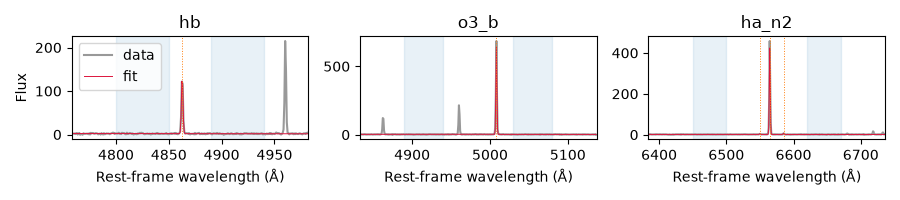

In [18]:
plot_fit_results(result, spec, z, fignum=4)
plt.show()

My estimate of NII S/N:  1.3091772623748879e-30
EmFit estimate of  S/N:  233.30331160244543

My estimate of N2:  -29.271543390162716
EmFit estimate   :  -1.9270404065358921

My estimate of R3:  0.4869461219369072
EmFit estimate   :  0.27240917821313365


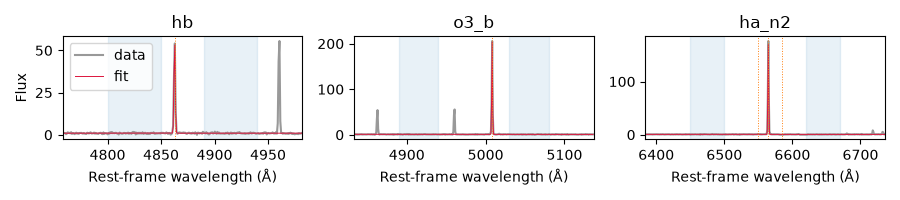

In [19]:
idx = 1
targetid = emps['TARGETID'].loc[idx]
spec = Table.read(f'../data/spectra/{targetid}.fits', format='fits')

z = emps['Z'].loc[idx]
N2 = emps['N2'].loc[idx]
R3 = emps['R3'].loc[idx]
ston = emps['ston'].loc[idx]

result = fit_spectrum_lines(f"../data/spectra/{targetid}.fits", z=z, emp_catalog_path="../data/emp-candidates.fits")

print("My estimate of NII S/N: ", result['ha_n2']['popt'][4] / result['ha_n2']['perr'][4])
print("EmFit estimate of  S/N: ", ston)
print("")
print("My estimate of N2: ", np.log10(result['ha_n2']['popt'][4] / result['ha_n2']['popt'][3]))
print("EmFit estimate   : ", N2)
print("")
print("My estimate of R3: ", np.log10(result['o3_b']['popt'][2] / result['hb']['popt'][2]))
print("EmFit estimate   : ", R3)



plot_fit_results(result, spec, z, fignum=5);
plt.show();

In [20]:
def report_and_plot(idx, fignum=None):
    targetid = emps['TARGETID'].loc[idx]
    spec = Table.read(f'../data/spectra/{targetid}.fits', format='fits')
    z = emps['Z'].loc[idx]
    N2 = emps['N2'].loc[idx]
    R3 = emps['R3'].loc[idx]
    ston = emps['ston'].loc[idx]

    result = fit_spectrum_lines(
        f'../data/spectra/{targetid}.fits',
        z=z,
        emp_catalog_path='../data/emp-candidates.fits',
    )

    print("My estimate of NII S/N: ", result['ha_n2']['popt'][4] / result['ha_n2']['perr'][4])
    print("EmFit estimate of  S/N: ", ston)
    print("")
    print("My estimate of N2: ", np.log10(result['ha_n2']['popt'][4] / result['ha_n2']['popt'][3]))
    print("EmFit estimate   : ", N2)
    print("")
    print("My estimate of R3: ", np.log10(result['o3_b']['popt'][2] / result['hb']['popt'][2]))
    print("EmFit estimate   : ", R3)

    plot_fit_results(result, spec, z, fignum=fignum)
    plt.show()
    return result

My estimate of NII S/N:  13.046692030102784
EmFit estimate of  S/N:  167.05669950696674

My estimate of N2:  -1.5277227588803604
EmFit estimate   :  -2.027290876686727

My estimate of R3:  0.13698187264750059
EmFit estimate   :  0.08394529171551475


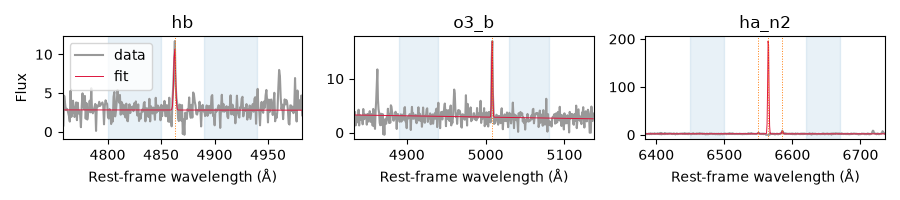

In [21]:
result = report_and_plot(2, fignum=6)

My estimate of NII S/N:  21.53420706504451
EmFit estimate of  S/N:  123.71086707994613

My estimate of N2:  -3.736665586008345
EmFit estimate   :  -2.9583934265792156

My estimate of R3:  0.3284810454856487
EmFit estimate   :  0.3013647159248882


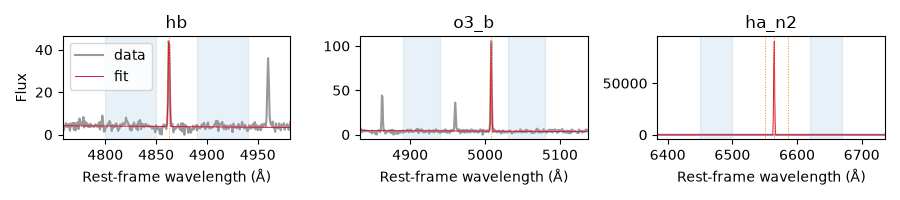

In [22]:
result = report_and_plot(3, fignum=7)

In [23]:
def plot_ha_nii(idx, fignum=None):
    targetid = emps['TARGETID'].loc[idx]
    spec = Table.read(f'../data/spectra/{targetid}.fits', format='fits')
    z = emps['Z'].loc[idx]

    result = fit_spectrum_lines(
        f'../data/spectra/{targetid}.fits',
        z=z,
        emp_catalog_path='../data/emp-candidates.fits',
    )

    ha_n2_result = result['ha_n2']
    nii_flux = ha_n2_result['popt'][4]
    nii_flux_error = ha_n2_result['perr'][4]
    nii_snr = nii_flux / nii_flux_error
    n2 = np.log10(nii_flux / ha_n2_result['popt'][3])

    print("NII S/N: ", nii_snr)
    print("N2: ", n2)
    print("EmFit catalog N2: ", emps['N2'].loc[idx])

    rest_wave = spec['wavelength'] / (1 + z)
    plot_mask = (
        (rest_wave >= ha_n2_window[0][0])
        & (rest_wave <= ha_n2_window[1][1])
    )
    model = make_gaussian_model(ha_n2)
    flux_model = model(spec['wavelength'][plot_mask], *ha_n2_result['popt'])

    y_values = np.concatenate((np.asarray(spec['flux'][plot_mask]), flux_model))
    y_min, y_max = np.nanmin(y_values), np.nanmax(y_values)
    y_pad = 0.15 * max(y_max - y_min, np.finfo(float).eps)

    fig, ax = plt.subplots(num=fignum, clear=True, figsize=(6, 4))
    ax.plot(rest_wave[plot_mask], spec['flux'][plot_mask], color='black', lw=0.7, label='data')
    ax.plot(rest_wave[plot_mask], flux_model, color='crimson', lw=1.2, label='fit')
    ax.axvline(6583.4, color='tab:blue', ls='--', lw=0.9, label='[N II] 6583')
    ax.set_xlim(ha_n2_window[0][0], ha_n2_window[1][1])
    ax.set_ylim(y_min - y_pad, y_max + y_pad)
    ax.set_xlabel('Rest-frame wavelength (Angstrom)')
    ax.set_ylabel('Flux')
    ax.set_title('H-alpha + [N II]')
    ax.legend()
    fig.tight_layout()
    plt.show()

    return result, fig, ax

NII S/N:  39.92866977962724
N2:  -4.277125626076357
EmFit catalog N2:  -3.9784327302858635


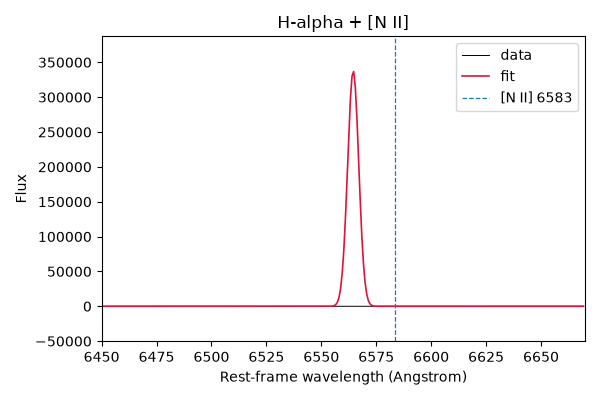

In [24]:
result = plot_ha_nii(10, fignum=8)